# Final Project Report:
## Koopman Transformer for Ventilator Pressure Prediction

### Team Members: Blake Willett, Ryan Farber

### Dataset for your project: https://www.kaggle.com/competitions/ventilator-pressure-prediction/data

---

# Lab 8 Content

## Understanding the Data



1.   Data size and structure: How big is the data? How is it structured? Are there any obvious patterns? If so, are they expected? Any unused features? Etc.
2.   Data cleanness: Is some of the data corrupted? Is some data mislabeled? If it's simulated, does the simulator have any limitations?
3. Diversity of features: How many features (e.g., # of pixels, # of columns) are there per data sample? Does your dataset have approximately equal number of datapoints per label?






Total Rows = 1048575 datapoints (80 samples per breath ~= 13100 Breaths)

Clean data. 7 columns, all with valid values.

**INPUTS**
* id - globally-unique time step identifier across an entire file
* breath_id - globally-unique time step for breaths
* R - lung attribute indicating how restricted the airway is (in cmH2O/L/S). Physically, this is the change in pressure per change in flow (air volume per time). Intuitively, one can imagine blowing up a balloon through a straw. We can change R by changing the diameter of the straw, with higher R being harder to blow.
* C - lung attribute indicating how compliant the lung is (in mL/cmH2O). Physically, this is the change in volume per change in pressure. Intuitively, one can imagine the same balloon example. We can change C by changing the thickness of the balloon’s latex, with higher C having thinner latex and easier to blow.
time_step - the actual time stamp.
* u_in - the control input for the inspiratory solenoid valve. Ranges from 0 to 100.
* u_out - the control input for the exploratory solenoid valve. Either 0 or 1.

**TARGET**
* pressure - the airway pressure measured in the respiratory circuit, measured in cmH2O.

## Understanding the Task

1.   What problem are you trying to solve with your neural network model? (e.g.,
classification or regression?)

Regression of pressure.

2. What is the significance of solving the problem?

Manual tuning of PID controlling of the ventilator is needed due to variability between patients. There is also the risk of "ringing" that occurs due to the resonant frequency of the system, which distorts the waveform the doctor has prescribed. Adjustments by the clinician can strain a hospital with high patient volume, so automating this process would be optimal.


3. What will be the evaluation metric for your neural network model?

The evaluation metric will be the total loss over a run utilizing an L1 norm. Our comparison to see how good our model is is to compared it to the other models within the competition.
Per competition, absolute difference in predicted and measured INSPIRATORY pressure.

4. What would constitute a good performance?

Beating a PID response baseline or getting in the top 1% of the competition. (Top 1% Cutoff: 0.1323 for 86th place)

5. Is there a baseline method to compare against after meeting the performance? (e.g., classical machine learning method, other neural network models)

We typically use PIDs for this task, thus we want to beat the accuracy of a basic PID detector. We can also see whether new transformer based technology can beat the LSTMs which were utilized in 2021.



## Developing an initial plan for your project



1.   What will be the inputs and outputs (including their dimensions) of your neural network model? • What data preparation methods do you plan to use?

(Described mostly in first section.) Some scaling. Chunk breaths, as the breaths are not continuous.

2. What neural network model do you plan to use? (FCN, CNN, RNN, etc)

Try a transformer, using Koopman encoded features to added information about the non-linear dyanmic system. Compare to an LSTM.

3. What loss function do you plan to use?

MAE, as this is the metric the competition uses. They specific use MAE of only the inhale phase, when u_out = 0.

4. How do you plan to evaluate your model?

Same as our loss function. MAE of predicted pressure was the metric of the competition. Additionally, we can consider inference time as a measure of feasibility for applications in real-time controls. One paper reported models taking 3 seconds to make a breath inference. A breath is only 3 seconds long to start with.



# Lab 9 Start

In [1]:
%pip install dlkoopman

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.

# Initial Data Preparation

In [1]:
# Imports for numerical preprocessing, PyTorch model training, plotting, and Colab file access.
import numpy as np
import pandas as pd
import time
import torch
from torch import nn
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset, TensorDataset
from dlkoopman.traj_pred import *
from dlkoopman import utils

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/PHYS417neuralNets/FinalProject

Mounted at /content/drive
/content/drive/MyDrive/PHYS417neuralNets/FinalProject


In [2]:
# Central configuration for data size, feature scaling, model architecture, and training hyperparameters.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # choose GPU in Colab when available
SEED = 69  # keeps train/val/test splits reproducible across all models

# DATA ============================================================================
SAMPLES_PER_BREATH = 80  # Kaggle ventilator breaths contain 80 samples
MAX_TRAIN_ROWS = 1_048_574
num_1k_breaths = 7  # How many 1000s of 80-sample breaths to load from the csv.
C_SCALE = 50.0
R_SCALE = 50.0
U_IN_SCALE = 100.0
TRAIN_PROP = 0.80
VAL_PROP = 0.10
PRESSURE_COLUMN = "pressure"
PRESSURE_FEATURES = ["R", "C", "time_step", "u_in", "u_out", "delta_time", PRESSURE_COLUMN]  # feature order used in model input tensors
HINT_FEATURES = ["R", "C", "time_step", "u_in", "u_out", "delta_time"]  # available current-breath features before pressure is known
PRESSURE_FEATURE_INDEX = PRESSURE_FEATURES.index(PRESSURE_COLUMN)  # pressure-channel index used when preventing target leakage
U_OUT_FEATURE_INDEX = PRESSURE_FEATURES.index("u_out") # Keep for optional masked MAE switching

# KOOPMAN ENCODING ================================================================
koopman_encoded_size = 50
KOOPMAN_EPOCHS = 20

# FIRST SAMPLE CNN  ===============================================================
cnn_kern_len = 5
cnn_out_channels = 16
CNN_HINT_HIDDEN_DIM = 64
CNN_HINT_EMBED_DIM = 32
NUM_FIRST_BATCHES = 256
cnn_hidden_layers = [128, 64]
CNN_DROPOUT = 0 # More hurtful than helpful. Default dropout=0.3
cnn_lr = 5e-4 # Currently Adam
NUM_FIRST_EPOCHS = 10
first_loss_func = torch.nn.L1Loss() # MAE loss (all first are part of inhale)
PREDICTION_BATCH_SIZE = 512

# SUBSEQUENT SAMPLE TRANSFORMER ===================================================
transformer_lr = 0.0002281 # Currently AdamW
NUM_SEQ_EPOCHS = 50
NUM_SEQ_BATCHES = 32
TRANSFORMER_D_MODEL = 475
TRANSFORMER_NHEAD = 5
TRANSFORMER_LAYERS = 4
TRANSFORMER_DROPOUT = 0.1
# Best tuned decoder widths from tested models: d_model -> 69 -> 63 -> 27 -> 1
TRANSFORMER_DECODER_LAYERS = [69, 63, 27]
seq_loss_func = torch.nn.L1Loss() # Active unmasked MAE loss; switch to masked_mae_loss below when needed
# NOTE: Added gradient clipping


# LSTM BASELINE (takes CNN, no Koopman Encoding) ==================================
lstm_hidden_dim = 128
lstm_layers = 2
lstm_lr = 0.001  # Currently Adam
lstm_batch_size = 32
LSTM_EPOCHS = 50

In [3]:
# Load an integer number of complete breaths from train.csv
nSamples = int(min(SAMPLES_PER_BREATH * num_1k_breaths * 1_000, MAX_TRAIN_ROWS))
train_df = pd.read_csv("train.csv", nrows=nSamples)
print(train_df.head())

   id  breath_id   R   C  time_step       u_in  u_out   pressure
0   1          1  20  50   0.000000   0.083334      0   5.837492
1   2          1  20  50   0.033652  18.383041      0   5.907794
2   3          1  20  50   0.067514  22.509278      0   7.876254
3   4          1  20  50   0.101542  22.808822      0  11.742872
4   5          1  20  50   0.135756  25.355850      0  12.234987


## Data Functions

In [4]:
# Preprocessing utilities: scale numeric features, preserve inverse-scaling constants, and split rows by breath.
def scale_df(df):
    # Scale continuous columns and standardize pressure while preserving rescaling constants.
    df = df.copy()
    df["C"] = df["C"] / C_SCALE
    df["R"] = df["R"] / R_SCALE
    df["u_in"] = df["u_in"] / U_IN_SCALE
    df["time_step"] = df["time_step"] / df["time_step"].max()

    mean_pressure = df[PRESSURE_COLUMN].mean()
    std_pressure = df[PRESSURE_COLUMN].std()
    # Standardize pressure so MAE loss is numerically stable. Mean/std are saved for cmH2O conversion.
    df[PRESSURE_COLUMN] = (df[PRESSURE_COLUMN] - mean_pressure) / std_pressure
    df["u_out"] = df["u_out"].astype(float)
    return df, mean_pressure, std_pressure


def split_breaths(df):
    # Return breaths in original breath_id order so previous-breath relationships stay valid.
    return [group.copy().reset_index(drop=True) for _, group in df.groupby("breath_id", sort=True)]


def add_delta_time(breaths):
    # Add per-breath time deltas without mutating the input breath dataframes
    enhanced = []
    for breath in breaths:
        breath = breath.copy()
        # Compute elapsed time within each breath. The first sample has no previous sample, so its delta is zero.
        breath["delta_time"] = breath["time_step"].diff().fillna(0.0)
        enhanced.append(breath)
    return enhanced

In [5]:
# Shared split utilities ensure Koopman, CNN, Transformer, and LSTM all use consistent breaths.
def make_permutation(num_items, seed=SEED):
    # Create one random order and reuse it across Koopman, CNN, and Transformer stages.
    rng = np.random.default_rng(seed=seed)
    return rng.permutation(num_items)


def split_indices_from_permutation(perm, train_prop=TRAIN_PROP, val_prop=VAL_PROP):
    # Split an already-randomized permutation into train/validation/test index arrays.
    num_items = len(perm)
    num_train = int(num_items * train_prop)
    num_val = int(num_items * val_prop)
    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]
    return train_idx, val_idx, test_idx


def take_by_indices(data, indices):
    # Index either tensors or Python lists using a shared split index array.
    if torch.is_tensor(data):
        return data[torch.as_tensor(indices, dtype=torch.long, device=data.device)]
    return [data[int(i)] for i in indices]

In [6]:
# Build scaled breath data once, then create one shared train/validation/test split for every model.
df_scaled, mean_pressure, std_pressure = scale_df(train_df)
breaths = add_delta_time(split_breaths(df_scaled))
num_breaths = len(breaths)
breath_perm = make_permutation(num_breaths, seed=SEED)
train_idx, val_idx, test_idx = split_indices_from_permutation(breath_perm)

print(f"Loaded {num_breaths:,} breaths")

# Prints heads of several breaths
for i in range(0,5,1):
  print(breaths[i].head())

Loaded 7,000 breaths
   id  breath_id    R    C  time_step      u_in  u_out  pressure  delta_time
0   1          1  0.4  1.0   0.000000  0.000833    0.0 -0.663092    0.000000
1   2          1  0.4  1.0   0.012255  0.183830    0.0 -0.654459    0.012255
2   3          1  0.4  1.0   0.024587  0.225093    0.0 -0.412721    0.012332
3   4          1  0.4  1.0   0.036979  0.228088    0.0  0.062120    0.012392
4   5          1  0.4  1.0   0.049439  0.253559    0.0  0.122555    0.012460
   id  breath_id    R    C  time_step      u_in  u_out  pressure  delta_time
0  81          2  0.4  0.4   0.000000  0.121843    0.0 -0.637192    0.000000
1  82          2  0.4  0.4   0.012381  0.139802    0.0 -0.455889    0.012381
2  83          2  0.4  0.4   0.024819  0.125742    0.0 -0.240052    0.012438
3  84          2  0.4  0.4   0.037168  0.117305    0.0 -0.110549    0.012349
4  85          2  0.4  0.4   0.049498  0.121242    0.0 -0.170984    0.012329
    id  breath_id    R    C  time_step      u_in  u_out

In [ ]:
# Optional masked MAE loss block to train models only on the portion of the breath relevant to the competition evaluation.
# Found masked MAE made the inhale phase more accurate (better for the competition), but the reported loss value stays similar when
# comparing model trained using inhale phase masked MAE loss evaluated in inhale phase only vs. normal MAE evaluated the entire breath.

# def masked_mae_loss(pred, target, u_out, exclude_first=True):
#     # MAE over samples where u_out == 0. Optionally ignore the first pressure sample.
#     if exclude_first:
#         pred = pred[:, 1:]
#         target = target[:, 1:]
#         u_out = u_out[:, 1:]

#     mask = (u_out == 0).to(dtype=pred.dtype)
#     abs_error = torch.abs(pred - target)

#     return (abs_error * mask).sum() / mask.sum().clamp_min(1.0)

# seq_loss_func = masked_mae_loss


# Designed Models

The following structure is used for each model (CNN, Transformer, and the baseline LSTM):
1. Prepare Data
2. Define Model
3. Define Hyperparameters (most of which the actual values are set at the top of the notebook)
4. Identify Tracked Values
5. Train Model
6. Visualize and Evalaute Model

The Koopman Encoder structure is slighlty different due to using prebuilt class and functions.


## Koopman Encoding

### Prepare Data

In [7]:
# Convert breath-level dataframes to tensors with shape [num_breaths, samples_per_breath, num_features].
def breaths_to_tensor(breath_list, included_features=PRESSURE_FEATURES):
    # Convert a list of equal-length breath dataframes into a 3D tensor.
    tensors = []
    for breath in tqdm(breath_list, desc="Tensorizing breaths"):
        tensors.append(torch.tensor(breath[included_features].values, dtype=torch.float32))
    return torch.stack(tensors)


koopman_data = breaths_to_tensor(breaths).to(DEVICE)
koopman_train = take_by_indices(koopman_data, train_idx)
koopman_val = take_by_indices(koopman_data, val_idx)
koopman_test = take_by_indices(koopman_data, test_idx)

print(koopman_train.shape, koopman_val.shape, koopman_test.shape)

Tensorizing breaths: 100%|██████████| 7000/7000 [00:03<00:00, 2122.47it/s]


torch.Size([5600, 80, 7]) torch.Size([700, 80, 7]) torch.Size([700, 80, 7])


### Train Model

In [8]:
# Train the Koopman autoencoder only on training breaths, then reuse its encoder as Transformer conditioning.
dh = TrajPredDataHandler(koopman_train)
tp = TrajPred(dh=dh, encoded_size=koopman_encoded_size)
tp.train_net(numepochs=KOOPMAN_EPOCHS)
koopman_encoder = tp.ae

Log file = /content/drive/MyDrive/PHYS417neuralNets/FinalProject/log_RySRMXTPofUh4CK6t7EwCa.log


100%|██████████| 20/20 [00:31<00:00,  1.58s/it]


### Functions to Utilize Koopman Encoder

In [9]:
# Encoder wrapper handles different dlkoopman return formats while keeping the Koopman model frozen.
def _first_tensor(obj):
    # Extract the tensor from encoder outputs that may be tensors, tuples, or lists.
    if torch.is_tensor(obj):
        return obj
    if isinstance(obj, (tuple, list)):
        for item in obj:
            if torch.is_tensor(item):
                return item
    raise TypeError(f"Koopman encoder returned unsupported type: {type(obj)!r}")


def encode_with_koopman(encoder, x):
    # Use the learned Koopman encoder and return a tensor usable as Transformer conditioning.
    was_training = encoder.training
    encoder.eval()
    with torch.no_grad():
        if hasattr(encoder, "encode"):
            encoded = encoder.encode(x)
        elif hasattr(encoder, "encoder"):
            encoded = encoder.encoder(x)
        else:
            encoded = encoder(x)
    if was_training:
        encoder.train()
    # Detach Koopman features so sequence-model gradients do not update the autoencoder.
    return _first_tensor(encoded).detach()


with torch.no_grad():
    sample_koopman_z = encode_with_koopman(koopman_encoder, koopman_train[:2])
print(f"Koopman encoding shape: {tuple(sample_koopman_z.shape)}")

Koopman encoding shape: (2, 80, 50)


## First Pressure Prediction Model

### Prepare Data

In [18]:
# First-pressure examples pair each current breath with the immediately previous breath.
def make_first_pressure_examples(breath_list):
    # Pair each breath with the immediately previous original-order breath and its true first pressure.
    examples, targets = [], []
    for current_idx in tqdm(range(1, len(breath_list)), desc="Building CNN examples"):
        previous_breath = breath_list[current_idx - 1]
        current_breath = breath_list[current_idx]
        examples.append({
            "prev_values": torch.tensor(previous_breath[PRESSURE_FEATURES].values, dtype=torch.float32), # Includes true pressure
            "current_hint": torch.tensor(current_breath[HINT_FEATURES].iloc[0].values, dtype=torch.float32), # Excludes true pressure
        })
        targets.append(float(current_breath[PRESSURE_COLUMN].iloc[0]))
    return examples, torch.tensor(targets, dtype=torch.float32)

first_input, first_target = make_first_pressure_examples(breaths)

# Reuse the exact shared split membership instead of re-splitting after dropping breath 0.
# This prevents validation/test breaths from accidentally moving into CNN training.
first_train_idx = train_idx[train_idx > 0]
first_val_idx = val_idx[val_idx > 0]
first_test_idx = test_idx[test_idx > 0]

# Map breath indices back to first-model example indices. Example 0 predicts breath 1.
# Example index is one less than breath index because breath 0 has no previous-breath example.
first_train_example_idx = first_train_idx - 1
first_val_example_idx = first_val_idx - 1
first_test_example_idx = first_test_idx - 1

first_train_input = take_by_indices(first_input, first_train_example_idx)
first_val_input = take_by_indices(first_input, first_val_example_idx)
first_test_input = take_by_indices(first_input, first_test_example_idx)
first_train_target = take_by_indices(first_target, first_train_example_idx).to(DEVICE)
first_val_target = take_by_indices(first_target, first_val_example_idx).to(DEVICE)
first_test_target = take_by_indices(first_target, first_test_example_idx).to(DEVICE)

print(len(first_train_input), first_train_target.shape)
print(first_train_input[0]["prev_values"].shape, first_train_input[0]["current_hint"].shape)


Building CNN examples: 100%|██████████| 6999/6999 [00:07<00:00, 973.58it/s]

5600 torch.Size([5600])
torch.Size([80, 7]) torch.Size([6])


### Define the Model

In [19]:
# Dataset and CNN for predicting the first pressure sample from previous-breath history plus current-breath metadata.
class FirstPredDataset(Dataset):
    # Dataset that moves nested first-pressure examples onto the training device.
    def __init__(self, input_data, output_data):
        if len(input_data) != len(output_data):
            raise ValueError("input and output data must be the same length")
        self.input_data = input_data
        self.output_data = output_data

    def __len__(self):
        return len(self.input_data)

    def __getitem__(self, idx):
        example = self.input_data[idx]
        return {
            "prev_values": example["prev_values"].to(DEVICE),
            "current_hint": example["current_hint"].to(DEVICE),
        }, self.output_data[idx].to(DEVICE)


class FirstPredCNN(torch.nn.Module):
    # Predict the current breath's first pressure from the previous full breath and current metadata.
    def __init__(
        self,
        ker_len=cnn_kern_len,
        out_channels=cnn_out_channels,
        hidden_layers=cnn_hidden_layers,
        dropout=CNN_DROPOUT,
        hint_hidden_dim=CNN_HINT_HIDDEN_DIM,
        hint_embed_dim=CNN_HINT_EMBED_DIM,
    ):
        super().__init__()
        if hidden_layers is None:
            hidden_layers = cnn_hidden_layers
        conv_embed_dim = out_channels * (SAMPLES_PER_BREATH - ker_len + 1)

        self.cnn = torch.nn.Sequential(
            torch.nn.Conv2d(1, out_channels, kernel_size=(ker_len, len(PRESSURE_FEATURES)), stride=1, padding=0),
            torch.nn.ReLU(),
            torch.nn.Flatten(start_dim=1),
        )
        self.current_hint_embed = torch.nn.Sequential(
            torch.nn.Linear(len(HINT_FEATURES), hint_hidden_dim), torch.nn.GELU(), torch.nn.Dropout(p=dropout),
            torch.nn.Linear(hint_hidden_dim, hint_embed_dim),
        )

        layer_dims = [conv_embed_dim + hint_embed_dim, *hidden_layers]
        layers = []
        for in_dim, out_dim in zip(layer_dims[:-1], layer_dims[1:]):
            layers.extend([torch.nn.Linear(in_dim, out_dim), torch.nn.GELU(), torch.nn.Dropout(p=dropout)])
        layers.append(torch.nn.Linear(layer_dims[-1], 1))
        self.regressor = torch.nn.Sequential(*layers)

    def forward(self, x):
        # Conv2d expects [batch, channel, time, features], so add a single channel dimension.
        previous = x["prev_values"].unsqueeze(1)
        previous_features = self.cnn(previous)
        hint_features = self.current_hint_embed(x["current_hint"])
        # Concatenate previous-breath CNN features with current-hint features before scalar regression.
        return self.regressor(torch.cat((previous_features, hint_features), dim=1)).squeeze(-1)


first_pred_cnn = FirstPredCNN().to(DEVICE)

### Define Hyperparameters and Identify Tracked Values

In [20]:
# Train the first-pressure CNN with ordinary MAE and track epoch-average train/validation errors.
first_optimizer = torch.optim.Adam(first_pred_cnn.parameters(), lr=cnn_lr)
first_train_loss_list = []
first_validation_loss_list = []

### Train the Model

In [21]:
train_loader = DataLoader(FirstPredDataset(first_train_input, first_train_target), batch_size=NUM_FIRST_BATCHES, shuffle=True)
validation_loader = DataLoader(FirstPredDataset(first_val_input, first_val_target), batch_size=NUM_FIRST_BATCHES, shuffle=False)

# Train on randomized examples whose previous-breath inputs still come from the original breath order.
for _ in tqdm(range(NUM_FIRST_EPOCHS), desc="Training first-pressure CNN"):
    first_pred_cnn.train()
    train_loss = 0.0
    train_count = 0
    for batch_x, batch_y in train_loader:
        first_optimizer.zero_grad()
        outputs = first_pred_cnn(batch_x)
        loss = first_loss_func(outputs, batch_y)
        loss.backward()
        first_optimizer.step()
        # Convert batch-average MAE to a weighted sum so partial final batches do not skew epoch averages.
        train_loss += loss.item() * batch_y.numel()
        train_count += batch_y.numel()

    first_pred_cnn.eval()
    val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for val_x, val_y in validation_loader:
            val_outputs = first_pred_cnn(val_x)
            batch_loss = first_loss_func(val_outputs, val_y)
            val_loss += batch_loss.item() * val_y.numel()
            val_count += val_y.numel()

    first_train_loss_list.append(train_loss / max(train_count, 1))
    first_validation_loss_list.append(val_loss / max(val_count, 1))

print(first_train_loss_list[-1], first_validation_loss_list[-1])
print(f"First-pressure training MAE: {first_train_loss_list[-1] * std_pressure:.4f} cmH2O")
print(f"First-pressure validation MAE: {first_validation_loss_list[-1] * std_pressure:.4f} cmH2O")


Training first-pressure CNN: 100%|██████████| 10/10 [00:03<00:00,  2.51it/s]

0.07598128672157015 0.08024294685055429
First-pressure training MAE: 0.6187 cmH2O
First-pressure validation MAE: 0.6534 cmH2O


### Visualize and Evaluate Model

In [22]:
# Generate first-pressure predictions in batches and evaluate held-out first-pressure MAE.
def predict_first_pressures(model, examples, batch_size=PREDICTION_BATCH_SIZE):
    # Run the first-pressure CNN over first-pressure examples without changing training state.
    was_training = model.training
    model.eval()
    dummy_targets = torch.zeros(len(examples), dtype=torch.float32, device=DEVICE)
    loader = DataLoader(FirstPredDataset(examples, dummy_targets), batch_size=batch_size, shuffle=False)
    predictions = []
    with torch.no_grad():
        for batch_x, _ in loader:
            predictions.append(model(batch_x).detach().cpu())
    if was_training:
        model.train()
    return torch.cat(predictions).to(DEVICE)


# Evaluate the first-pressure CNN on the held-out split using the true first pressures as targets.
first_pred_cnn.eval()
with torch.no_grad():
    first_test_predictions = predict_first_pressures(first_pred_cnn, first_test_input)
    first_scaled_mae = torch.nn.functional.l1_loss(first_test_predictions, first_test_target).item()
    first_original_mae = first_scaled_mae * std_pressure

print(f"First-pressure original-pressure MAE: {first_original_mae:.4f} cmH2O")

First-pressure original-pressure MAE: 0.6147 cmH2O


In [23]:
# Compare the first-pressure CNN against a constant-mean baseline to see whether it learned beyond the mean.
# Evaluate if CNN is actual improvement over mean of first pressures --> Conclusion: Barely
y_mean = first_test_target.mean()
mean_pred = torch.full_like(first_test_target, y_mean)
mean_mae_scaled = torch.mean(torch.abs(mean_pred - first_test_target))
cnn_mae_scaled = torch.mean(torch.abs(first_test_predictions - first_test_target))

# Evaluate the scaled MAE magnitude relative the scaled mean
print("Train first-pressure mean:", y_mean.item())
print("Constant mean baseline scaled MAE:", mean_mae_scaled.item())
print("CNN scaled MAE:", cnn_mae_scaled.item())

# Comparing deviation in scaled pressure values and deviation in predicted values ---> Mostly predicting the mean with small variance
print("\nTrue first-pressure std:", first_test_target.std().item())
print("CNN prediction std:", first_test_predictions.std().item())
print("CNN improvement over baseline:", (1 - cnn_mae_scaled.item() / mean_mae_scaled.item())*100, '%')

Train first-pressure mean: -0.6648806929588318
Constant mean baseline scaled MAE: 0.0869111716747284
CNN scaled MAE: 0.0754944384098053

True first-pressure std: 0.1236601322889328
CNN prediction std: 0.010259291157126427
CNN improvement over baseline: 13.136094065848148 %


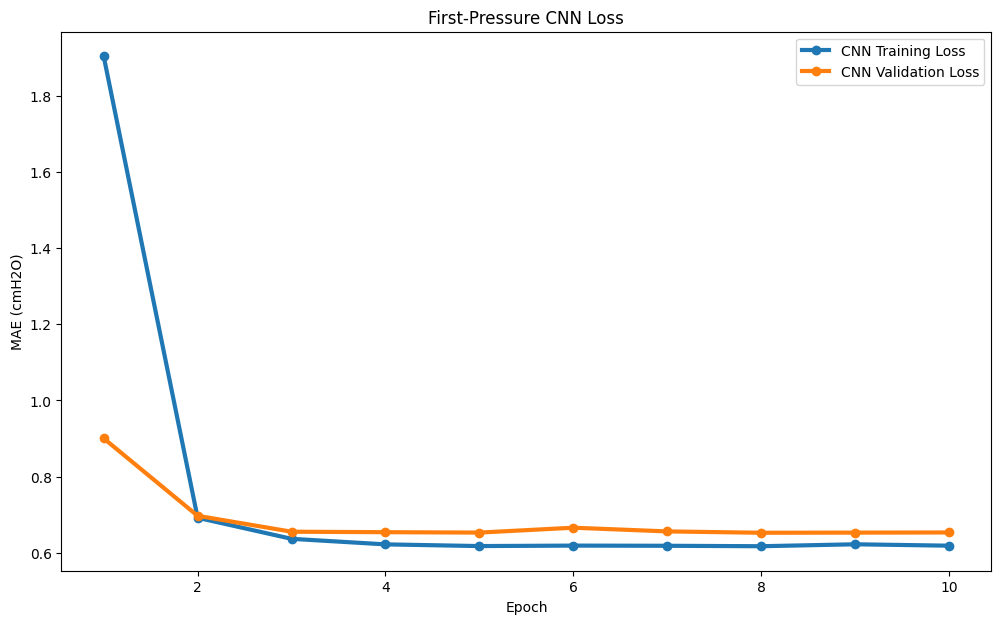

In [24]:
# Plot first-pressure CNN train/validation MAE curve after converting back to original pressure units of cmH2O.
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(first_train_loss_list) + 1), np.asarray(first_train_loss_list) * std_pressure, marker='o', linewidth=3, label='CNN Training Loss')
plt.plot(range(1, len(first_validation_loss_list) + 1), np.asarray(first_validation_loss_list) * std_pressure, marker='o', linewidth=3, label='CNN Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE (cmH2O)')
plt.title('First-Pressure CNN Loss')
plt.legend()
plt.show()

## Transformer Subsequent Pressure Model

### Prepare the Data

In [25]:
# Build sequence-model inputs while hiding future pressure values to avoid target leakage.
def make_sequence_data(breath_list, included_features=PRESSURE_FEATURES):
    # Create raw Transformer inputs and pressure targets for each breath.
    x_data, y_data = [], []
    for breath in tqdm(breath_list, desc="Building Transformer data"):
        x_data.append(breath[included_features].values)
        y_data.append(breath[PRESSURE_COLUMN].values)
    return (
        torch.tensor(np.asarray(x_data), dtype=torch.float32, device=DEVICE),
        torch.tensor(np.asarray(y_data), dtype=torch.float32, device=DEVICE),
    )


def build_cnn_first_pressure_lookup(model, examples, seq_targets):
    # Create one first-pressure value per breath, using true breath 0 and CNN predictions for later breaths.
    true_first_pressure = seq_targets[:, 0].detach().clone()
    cnn_first_pressure = true_first_pressure.clone()
    cnn_first_pressure[1:] = predict_first_pressures(model, examples)
    return true_first_pressure, cnn_first_pressure


def make_transformer_pressure_inputs(raw_x, first_pressure_values):
    # Expose only the chosen first pressure in the pressure channel to avoid target leakage.
    x = raw_x.clone()
    # Zero the full pressure channel first, then restore only the first pressure sample as known context.
    x[:, :, PRESSURE_FEATURE_INDEX] = 0.0
    x[:, 0, PRESSURE_FEATURE_INDEX] = first_pressure_values.to(device=x.device, dtype=x.dtype)
    return x


seq_input_raw, seq_target_data = make_sequence_data(breaths)
true_first_pressure_by_breath, cnn_first_pressure_by_breath = build_cnn_first_pressure_lookup(
    first_pred_cnn,
    first_input,
    seq_target_data,
)

# Training uses true first pressure. Validation/test/inference use CNN-predicted first pressure.
seq_train_raw = take_by_indices(seq_input_raw, train_idx)
seq_val_raw = take_by_indices(seq_input_raw, val_idx)
seq_test_raw = take_by_indices(seq_input_raw, test_idx)
seq_train_target = take_by_indices(seq_target_data, train_idx)
seq_val_target = take_by_indices(seq_target_data, val_idx)
seq_test_target = take_by_indices(seq_target_data, test_idx)
# Training uses true first pressure. Validation/test use CNN-predicted first pressure to match inference.
seq_train_input = make_transformer_pressure_inputs(seq_train_raw, take_by_indices(true_first_pressure_by_breath, train_idx))
seq_val_input = make_transformer_pressure_inputs(seq_val_raw, take_by_indices(cnn_first_pressure_by_breath, val_idx))
seq_test_input = make_transformer_pressure_inputs(seq_test_raw, take_by_indices(cnn_first_pressure_by_breath, test_idx))

print(seq_train_input.shape, seq_train_target.shape)


Building Transformer data: 100%|██████████| 7000/7000 [00:02<00:00, 2532.14it/s]


torch.Size([5600, 80, 7]) torch.Size([5600, 80])


### Define the Model

In [26]:
# Koopman-conditioned Transformer: append Koopman features, add position encoding, run self-attention, then decode pressure.
class PositionalEncoding(torch.nn.Module):
    # Fixed sinusoidal positional encoding for breath time steps.
    def __init__(self, d_model, max_len=SAMPLES_PER_BREATH):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SeqPredModel(torch.nn.Module):
    # Predict pressure at each time step using physical inputs plus Koopman conditioning.
    def __init__(
        self,
        feature_dim,
        koopman_dim,
        d_model=TRANSFORMER_D_MODEL,
        nhead=TRANSFORMER_NHEAD,
        num_layers=TRANSFORMER_LAYERS,
        dropout=TRANSFORMER_DROPOUT,
        decoder_layers=TRANSFORMER_DECODER_LAYERS,
    ):
        super().__init__()

        # PyTorch multi-head attention requires d_model to be divisible by nhead
        d_model = (d_model // nhead) * nhead

        self.koopman_dim = koopman_dim
        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers
        self.decoder_layers = decoder_layers

        self.input_projection = torch.nn.Linear(feature_dim + koopman_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = torch.nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = torch.nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        decoder_modules = []
        layer_widths = [d_model] + list(decoder_layers)

        for in_dim, out_dim in zip(layer_widths[:-1], layer_widths[1:]):
            decoder_modules.append(torch.nn.Linear(in_dim, out_dim))
            decoder_modules.append(torch.nn.GELU())
            decoder_modules.append(torch.nn.Dropout(p=dropout))

        decoder_modules.append(torch.nn.Linear(layer_widths[-1], 1))
        self.decoder = torch.nn.Sequential(*decoder_modules)

    def _expand_koopman(self, x, koopman_z):
        if koopman_z.ndim == 2:
            # For one latent vector per breath, repeat it across all 80 time samples.
            return koopman_z.unsqueeze(1).expand(-1, x.size(1), -1)
        if koopman_z.ndim == 3:
            return koopman_z[:, :x.size(1), :]
        raise ValueError(f"Expected 2D or 3D Koopman encoding, got shape {tuple(koopman_z.shape)}")

    def forward(self, x, koopman_z):
        koopman_features = self._expand_koopman(x, koopman_z)
        x = torch.cat((x, koopman_features), dim=-1)
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        memory = self.transformer_encoder(x)
        return self.decoder(memory).squeeze(-1)


koopman_dim = sample_koopman_z.shape[-1]
seq_pred_model = SeqPredModel(feature_dim=len(PRESSURE_FEATURES), koopman_dim=koopman_dim).to(DEVICE)

### Define Hyperparameters and Identify Tracked Values

In [27]:
# Train the Transformer using unmasked MAE for now. Masked-MAE alternatives are commented out
seq_optimizer = torch.optim.AdamW(seq_pred_model.parameters(), lr=transformer_lr, weight_decay=1e-4)
seq_train_loss_list = []
seq_validation_loss_list = []

### Train the Model
Note: Took ~10 min to train.

In [ ]:
train_loader = DataLoader(TensorDataset(seq_train_input, seq_train_target), batch_size=NUM_SEQ_BATCHES, shuffle=True)
validation_loader = DataLoader(TensorDataset(seq_val_input, seq_val_target), batch_size=NUM_SEQ_BATCHES, shuffle=False)

# Train with true first pressure, then validate with the same CNN-predicted first-pressure path used at inference.
for _ in tqdm(range(NUM_SEQ_EPOCHS), desc="Training Transformer"):
    seq_pred_model.train()
    train_loss = 0.0
    train_count = 0
    for batch_x, batch_y in tqdm(train_loader, leave=False):
        seq_optimizer.zero_grad()
        koopman_z = encode_with_koopman(koopman_encoder, batch_x)
        pressure_predictions = seq_pred_model(batch_x, koopman_z)

        # Unmasked loss excludes sample 0 because the first pressure is supplied as input context.
        loss = seq_loss_func(pressure_predictions[:, 1:], batch_y[:, 1:])

        # To switch back to masked MAE, uncomment this block and the mask-count accumulation below.
        # # Masked MAE loss
        # batch_u_out = batch_x[:, :, U_OUT_FEATURE_INDEX]
        # loss = seq_loss_func(pressure_predictions, batch_y, batch_u_out, exclude_first=True)

        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(seq_pred_model.parameters(), max_norm=1.0)
        seq_optimizer.step()

        # train_mask_count = (batch_u_out[:, 1:] == 0).sum().item()
        # train_loss += loss.item() * train_mask_count
        # train_count += train_mask_count

        train_loss += loss.item() * batch_y[:, 1:].numel()
        train_count += batch_y[:, 1:].numel()

    seq_pred_model.eval()
    val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for val_x, val_y in validation_loader:
            val_koopman_z = encode_with_koopman(koopman_encoder, val_x)
            val_predictions = seq_pred_model(val_x, val_koopman_z)

            # Validation uses the same exclude-first MAE definition as training
            batch_loss = seq_loss_func(val_predictions[:, 1:], val_y[:, 1:])
            # val_u_out = val_x[:, :, U_OUT_FEATURE_INDEX]
            # batch_loss = seq_loss_func(val_predictions, val_y, val_u_out, exclude_first=True)

            val_loss += batch_loss.item() * val_y[:, 1:].numel()
            val_count += val_y[:, 1:].numel()
            # val_mask_count = (val_u_out[:, 1:] == 0).sum().item()
            # val_loss += batch_loss.item() * val_mask_count
            # val_count += val_mask_count

    seq_train_loss_list.append(train_loss / max(train_count, 1))
    seq_validation_loss_list.append(val_loss / max(val_count, 1))

print(seq_train_loss_list[-1], seq_validation_loss_list[-1])
print(f"Transformer training MAE excluding first pressure: {seq_train_loss_list[-1] * std_pressure:.4f} cmH2O")
print(f"Transformer validation MAE excluding first pressure: {seq_validation_loss_list[-1] * std_pressure:.4f} cmH2O")

Training Transformer: 100%|██████████| 50/50 [11:31<00:00, 13.84s/it]

0.0813849977510316 0.07176253616809845
Transformer training MAE excluding first pressure: 0.6627 cmH2O
Transformer validation MAE excluding first pressure: 0.5844 cmH2O


### Visualize and Evaluate the Model

In [ ]:
# Evaluate the Transformer with unmasked MAE. Masked-MAE lines are commented out.
def evaluate_sequence_model(model, encoder, x_data, y_data):
    # Evaluate unmasked pressure MAE and assemble the full predicted sequence.
    model.eval()

    with torch.no_grad():
        koopman_z = encode_with_koopman(encoder, x_data)
        predictions = model(x_data, koopman_z)

        full_predictions = predictions.clone()
        # Restore the supplied first pressure so full-pipeline MAE includes the known initial condition.
        full_predictions[:, 0] = x_data[:, 0, PRESSURE_FEATURE_INDEX]

        later_scaled_mae = seq_loss_func(predictions[:, 1:], y_data[:, 1:]).item()  # unmasked MAE excluding known first pressure
        full_scaled_mae = seq_loss_func(full_predictions, y_data).item()  # unmasked MAE over all 80 samples after restoring sample 0

        # u_out = x_data[:, :, U_OUT_FEATURE_INDEX]
        # later_scaled_mae = masked_mae_loss(predictions, y_data, u_out, exclude_first=True).item()
        # full_scaled_mae = masked_mae_loss(full_predictions, y_data, u_out, exclude_first=False).item()

    return {
        "later_scaled_mae": later_scaled_mae,
        "later_original_mae": later_scaled_mae * std_pressure,
        "full_scaled_mae": full_scaled_mae,
        "full_original_mae": full_scaled_mae * std_pressure,
    }


seq_metrics = evaluate_sequence_model(seq_pred_model, koopman_encoder, seq_test_input, seq_test_target)
print(f"Transformer original-pressure MAE excluding first pressure: {seq_metrics['later_original_mae']:.4f}")
print(f"Full pipeline original-pressure MAE: {seq_metrics['full_original_mae']:.4f}")


Transformer original-pressure MAE excluding first pressure: 0.5706
Full pipeline original-pressure MAE: 0.5711


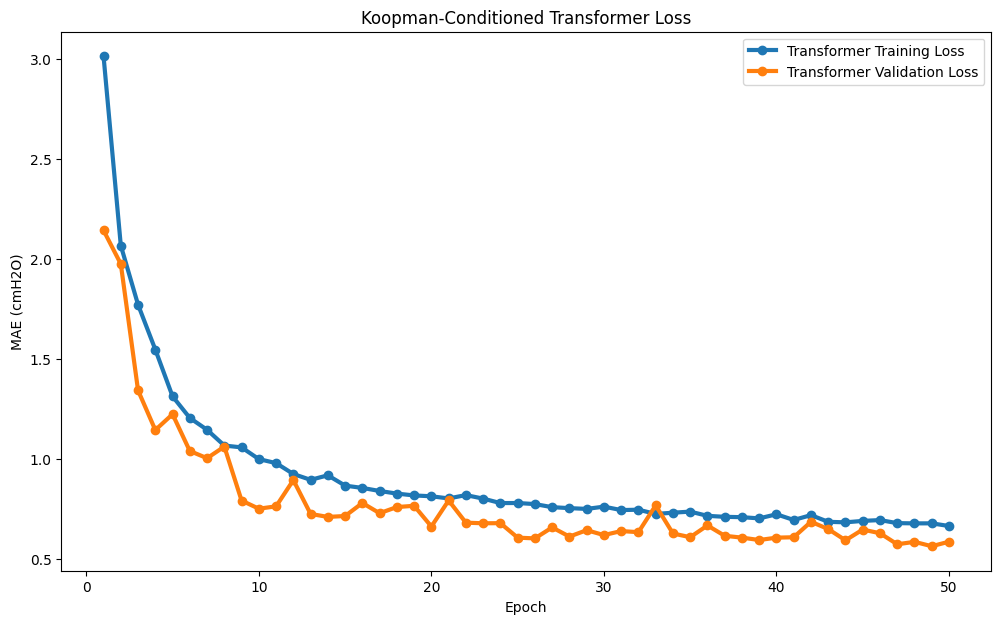

In [ ]:
# Plot Transformer train/validation MAE in cmH2O, excluding the known first pressure sample

plt.figure(figsize=(12, 7))
plt.plot(range(1, len(seq_train_loss_list) + 1), np.asarray(seq_train_loss_list) * std_pressure, marker='o', linewidth=3, label='Transformer Training Loss')
plt.plot(range(1, len(seq_validation_loss_list) + 1), np.asarray(seq_validation_loss_list) * std_pressure, marker='o', linewidth=3, label='Transformer Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE (cmH2O)')
plt.title('Koopman-Conditioned Transformer Loss')
plt.legend()
plt.show()

In [ ]:
# OPT: Export CNN and Transformer loss histories for Excel or MATLAB plotting.
# First-pressure CNN training curve.
cnn_curve_df = pd.DataFrame({
    "epoch": range(1, len(first_train_loss_list) + 1),
    "cnn_training_mae_cmH2O": np.asarray(first_train_loss_list) * std_pressure,
    "cnn_validation_mae_cmH2O": np.asarray(first_validation_loss_list) * std_pressure,
})

cnn_curve_df.to_csv("cnn_training_curve.csv", index=False)

# Koopman-conditioned Transformer training curve.
transformer_curve_df = pd.DataFrame({
    "epoch": range(1, len(seq_train_loss_list) + 1),
    "transformer_training_mae_cmH2O": np.asarray(seq_train_loss_list) * std_pressure,
    "transformer_validation_mae_cmH2O": np.asarray(seq_validation_loss_list) * std_pressure,
})

transformer_curve_df.to_csv("koopman_transformer_training_curve.csv", index=False)

# LSTM Baseline for Comparison

This baseline replaces the Koopman-conditioned Transformer with an LSTM while using the same CNN-provided first pressure and the same data split.

### Define the Model
Data Preparation alreay done for earlier models.

In [ ]:
# LSTM baseline uses the same sequence inputs as the Transformer but does not use Koopman conditioning.
class SubsequentLSTMModel(nn.Module):
    # Predict subsequent pressure values from per-time-step physical inputs and the CNN first-pressure channel.
    def __init__(self, input_size, lstm_hidden_dim=lstm_hidden_dim, num_lstm_layers=lstm_layers, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=lstm_hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0,
        )
        self.out_head = nn.Sequential(
            nn.LayerNorm(lstm_hidden_dim),
            nn.Linear(lstm_hidden_dim, lstm_hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden_dim // 2, 1),
        )

    def forward(self, x_seq):
        h, _ = self.lstm(x_seq)
        return self.out_head(h).squeeze(-1)

### Define Hyperparameters and Identify Tracked Values

In [ ]:
lstm_model = SubsequentLSTMModel(input_size=seq_train_input.shape[-1]).to(DEVICE)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=lstm_lr)
lstm_train_loss_list = []
lstm_val_loss_list = []

### Train the LSTM Model

In [ ]:
# Train the LSTM baseline with unmasked MAE. Masked-MAE is commented out.
lstm_train_loader = DataLoader(TensorDataset(seq_train_input, seq_train_target), batch_size=lstm_batch_size, shuffle=True)
lstm_val_loader = DataLoader(TensorDataset(seq_val_input, seq_val_target), batch_size=lstm_batch_size, shuffle=False)

# Train on true first pressure, then validate with the same CNN-predicted first-pressure path used at inference.
for _ in tqdm(range(LSTM_EPOCHS), desc='Training LSTM baseline'):
    lstm_model.train()
    train_loss = 0.0
    train_count = 0
    for batch_x, batch_y in lstm_train_loader:
        lstm_optimizer.zero_grad()
        pressure_predictions = lstm_model(batch_x)

        # Loss excludes the first pressure sample, matching the Transformer objective.
        loss = seq_loss_func(pressure_predictions[:, 1:], batch_y[:, 1:])  # unmasked MAE over samples 1-79
        # batch_u_out = batch_x[:, :, U_OUT_FEATURE_INDEX]
        # loss = masked_mae_loss(pressure_predictions, batch_y, batch_u_out, exclude_first=True)

        loss.backward()

        # Clip recurrent-model gradients to reduce exploding-gradient behavior
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        lstm_optimizer.step()
        train_loss += loss.item() * batch_y[:, 1:].numel()
        train_count += batch_y[:, 1:].numel()

    lstm_model.eval()
    val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for val_x, val_y in lstm_val_loader:
            val_predictions = lstm_model(val_x)

            batch_loss = seq_loss_func(val_predictions[:, 1:], val_y[:, 1:])
            # val_u_out = val_x[:, :, U_OUT_FEATURE_INDEX]
            # batch_loss = masked_mae_loss(val_predictions, val_y, val_u_out, exclude_first=True)

            val_loss += batch_loss.item() * val_y[:, 1:].numel()
            val_count += val_y[:, 1:].numel()

    lstm_train_loss_list.append(train_loss / max(train_count, 1))
    lstm_val_loss_list.append(val_loss / max(val_count, 1))

print(lstm_train_loss_list[-1], lstm_val_loss_list[-1])
print(f"LSTM training MAE excluding first pressure: {lstm_train_loss_list[-1] * std_pressure:.4f} cmH2O")
print(f"LSTM validation MAE excluding first pressure: {lstm_val_loss_list[-1] * std_pressure:.4f} cmH2O")


Training LSTM baseline: 100%|██████████| 50/50 [00:35<00:00,  1.39it/s]

0.08518208226987294 0.10027473360300064
LSTM training MAE excluding first pressure: 0.6936 cmH2O
LSTM validation MAE excluding first pressure: 0.8165 cmH2O


### Visualize and Evaluate LSTM Baseline

In [ ]:
# Evaluate LSTM baseline with unmasked MAE. Masked MAE is commented out.
def evaluate_lstm_model(model, x_data, y_data):
    # Evaluate unmasked LSTM MAE and assemble the full predicted sequence.
    model.eval()

    with torch.no_grad():
        predictions = model(x_data)

        full_predictions = predictions.clone()
        full_predictions[:, 0] = x_data[:, 0, PRESSURE_FEATURE_INDEX]

        later_scaled_mae = seq_loss_func(predictions[:, 1:], y_data[:, 1:]).item()
        full_scaled_mae = seq_loss_func(full_predictions, y_data).item()

        # u_out = x_data[:, :, U_OUT_FEATURE_INDEX]
        # later_scaled_mae = masked_mae_loss(predictions, y_data, u_out, exclude_first=True).item()
        # full_scaled_mae = masked_mae_loss(full_predictions, y_data, u_out, exclude_first=False).item()

    return {
        "later_scaled_mae": later_scaled_mae,
        "later_original_mae": later_scaled_mae * std_pressure,
        "full_scaled_mae": full_scaled_mae,
        "full_original_mae": full_scaled_mae * std_pressure,
    }


lstm_metrics = evaluate_lstm_model(lstm_model, seq_test_input, seq_test_target)
print(f"LSTM MAE excluding first pressure: {lstm_metrics['later_original_mae']:.4f} cmH2O")
print(f"Full LSTM pipeline MAE: {lstm_metrics['full_original_mae']:.4f} cmH2O")


LSTM MAE excluding first pressure: 0.8065 cmH2O
Full LSTM pipeline MAE: 0.8041 cmH2O


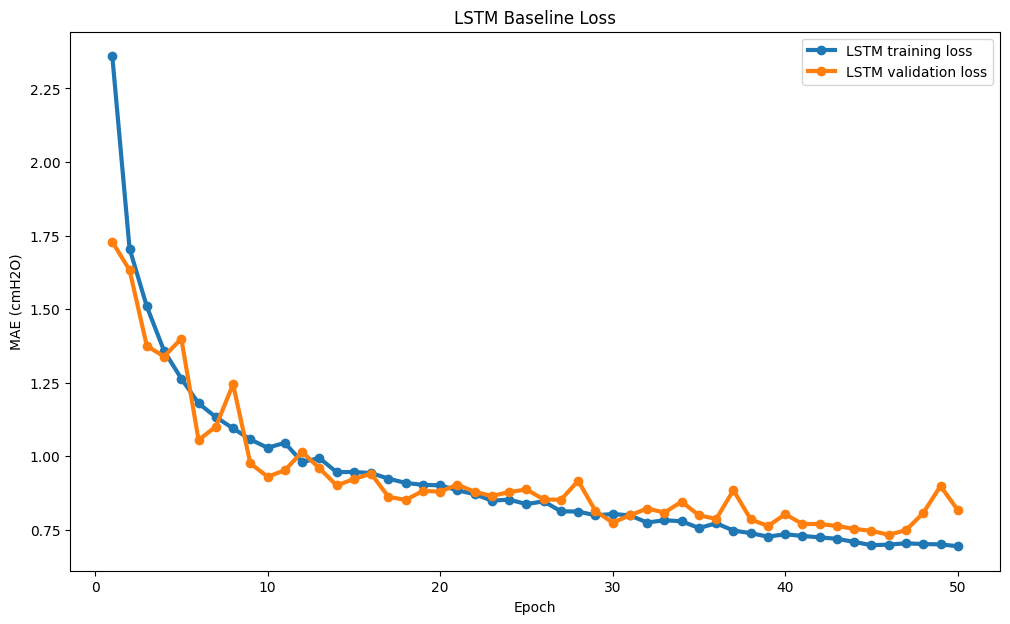

In [ ]:
# Plot LSTM train/validation MAE in cmH2O, excluding the known first pressure sample.
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(lstm_train_loss_list) + 1), np.asarray(lstm_train_loss_list) * std_pressure, marker='o', linewidth=3, label='LSTM training loss')
plt.plot(range(1, len(lstm_val_loss_list) + 1), np.asarray(lstm_val_loss_list) * std_pressure, marker='o', linewidth=3, label='LSTM validation loss')
plt.xlabel('Epoch')
plt.ylabel('MAE (cmH2O)')
plt.title('LSTM Baseline Loss')
plt.legend()
plt.show()

In [ ]:
# Export LSTM loss history for Excel or MATLAB plotting.
lstm_curve_df = pd.DataFrame({
    "epoch": range(1, len(lstm_train_loss_list) + 1),
    "lstm_training_mae_cmH2O": np.asarray(lstm_train_loss_list) * std_pressure,
    "lstm_validation_mae_cmH2O": np.asarray(lstm_val_loss_list) * std_pressure,
})

lstm_curve_df.to_csv("lstm_training_curve.csv", index=False)

lstm_curve_df.head()

,epoch,lstm_training_mae_cmH2O,lstm_validation_mae_cmH2O
0,1,2.359748,1.728401
1,2,1.705887,1.632692
2,3,1.508965,1.374956
3,4,1.358010,1.338598
4,5,1.263559,1.399600


# Baseline LSTM vs Transformer-Pipeline vs True Pressure

Compare in a plot the true pressure, LSTM pressure, and Koopman/CNN/Transformer pipeline pressure for three breaths from the test split.

Transformer pipeline inference time: 2.3074 ms/breath (3 breaths)
LSTM pipeline inference time: 0.3841 ms/breath (3 breaths)


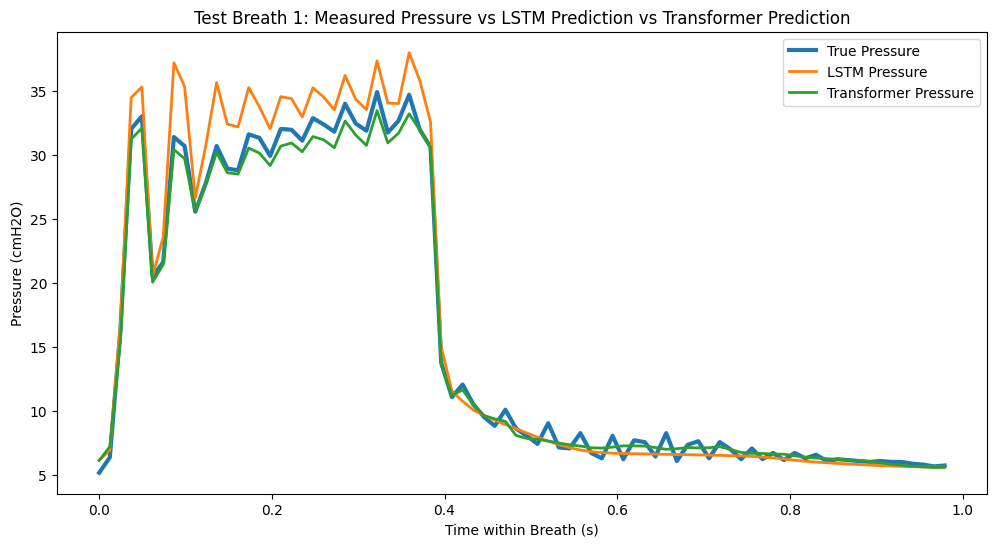

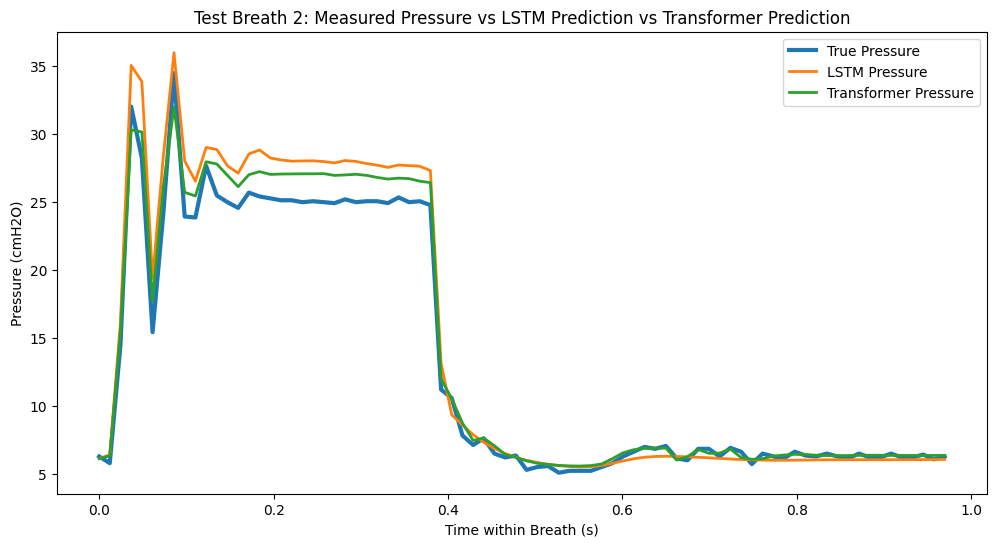

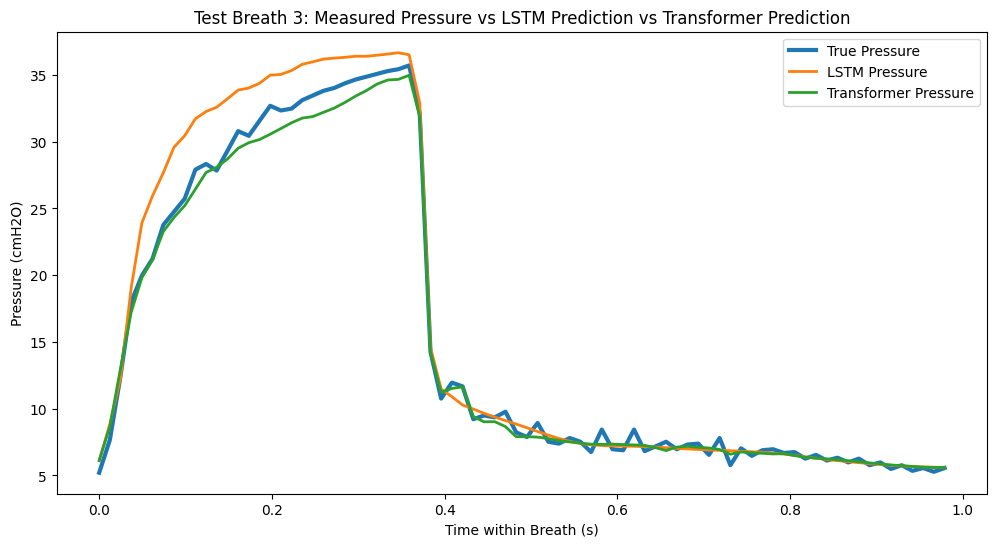

In [ ]:
# Run final full-pipeline predictions, time inference, and plot true pressure against LSTM and Transformer predictions.
def to_original_pressure(x):
    # Convert standardized pressure tensors or arrays back to the original pressure units.
    if torch.is_tensor(x):
        return (x.detach().cpu().numpy() * std_pressure) + mean_pressure
    return (np.asarray(x) * std_pressure) + mean_pressure


# Next two functions help report inference time
def _sync_if_cuda(x):
    # Synchronize CUDA work before/after timing so GPU inference timing is accurate.
    if torch.is_tensor(x) and x.is_cuda:
        torch.cuda.synchronize(x.device)

def _print_inference_time(label, elapsed_seconds, num_breaths):
    # Report inference timing normalized by breath count.
    breaths = max(int(num_breaths), 1)
    ms_per_breath = (elapsed_seconds / breaths) * 1000.0
    print(f"{label} inference time: {ms_per_breath:.4f} ms/breath ({breaths} breaths)")


def predict_transformer_pipeline(model, encoder, x_data, report_timing=True):
    # Return full Transformer-pipeline predictions with the CNN first pressure preserved.
    model.eval()
    _sync_if_cuda(x_data)
    start_time = time.perf_counter()
    with torch.no_grad():
        koopman_z = encode_with_koopman(encoder, x_data)
        predictions = model(x_data, koopman_z)
        full_predictions = predictions.clone()
        # Preserve the first pressure supplied to the sequence model so plotted output represents the full pipeline.
        full_predictions[:, 0] = x_data[:, 0, PRESSURE_FEATURE_INDEX]
    _sync_if_cuda(full_predictions)
    elapsed_seconds = time.perf_counter() - start_time
    if report_timing:
        _print_inference_time("Transformer pipeline", elapsed_seconds, x_data.shape[0])
    return full_predictions


def predict_lstm_pipeline(model, x_data, report_timing=True):
    # Return full LSTM-pipeline predictions with the CNN first pressure preserved.
    model.eval()
    _sync_if_cuda(x_data)
    start_time = time.perf_counter()
    with torch.no_grad():
        predictions = model(x_data)
        full_predictions = predictions.clone()
        full_predictions[:, 0] = x_data[:, 0, PRESSURE_FEATURE_INDEX]
    _sync_if_cuda(full_predictions)
    elapsed_seconds = time.perf_counter() - start_time
    if report_timing:
        _print_inference_time("LSTM pipeline", elapsed_seconds, x_data.shape[0])
    return full_predictions


num_plot_breaths = min(3, seq_test_input.shape[0])
plot_x = seq_test_input[:num_plot_breaths]
plot_y_true = seq_test_target[:num_plot_breaths]
plot_y_transformer = predict_transformer_pipeline(seq_pred_model, koopman_encoder, plot_x)
plot_y_lstm = predict_lstm_pipeline(lstm_model, plot_x)

time_steps = plot_x[:, :, 2].detach().cpu().numpy()  # Use cumulative time within each breath.
true_pressure = to_original_pressure(plot_y_true)
transformer_pressure = to_original_pressure(plot_y_transformer)
lstm_pressure = to_original_pressure(plot_y_lstm)

for breath_num in range(num_plot_breaths):
    plt.figure(figsize=(12, 6))
    plt.plot(time_steps[breath_num], true_pressure[breath_num], linewidth=3, label='True Pressure')
    plt.plot(time_steps[breath_num], lstm_pressure[breath_num], linewidth=2, label='LSTM Pressure')
    plt.plot(time_steps[breath_num], transformer_pressure[breath_num], linewidth=2, label='Transformer Pressure')
    plt.xlabel('Time within Breath (s)')
    plt.ylabel('Pressure (cmH2O)')
    plt.title(f'Test Breath {breath_num + 1}: Measured Pressure vs LSTM Prediction vs Transformer Prediction')
    plt.legend()
    plt.show()

In [ ]:
# OPT: Export the plotted pressure traces as a long-form CSV with one row per breath sample
time_steps = plot_x[:, :, 2].detach().cpu().numpy()
u_out = plot_x[:, :, U_OUT_FEATURE_INDEX].detach().cpu().numpy()

rows = []

for breath_num in range(num_plot_breaths):
    for i in range(len(time_steps[breath_num])):
        rows.append({
            "breath_num": breath_num + 1,
            "time_within_breath_s": time_steps[breath_num][i],
            "u_out": u_out[breath_num][i],
            "true_pressure_cmH2O": true_pressure[breath_num][i],
            "lstm_pressure_cmH2O": lstm_pressure[breath_num][i],
            "transformer_pressure_cmH2O": transformer_pressure[breath_num][i],
        })

df_plot = pd.DataFrame(rows)

df_plot.to_csv("breath_pressure_predictions.csv", index=False)

df_plot.head()

,breath_num,time_within_breath_s,u_out,true_pressure_cmH2O,lstm_pressure_cmH2O,transformer_pressure_cmH2O
0,1,0.000000,0.0,5.204773,6.164015,6.164015
1,1,0.012341,0.0,6.399909,6.970702,7.236279
2,1,0.024694,0.0,16.453115,16.951754,15.576672
3,1,0.037061,0.0,32.060192,34.505859,31.259449
4,1,0.049435,0.0,33.044422,35.343285,32.126823


# Optimize Sequence Model

In [13]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.0 MB/s eta 0:00:00


## Define Helper Functions

In [14]:
import optuna
from optuna import Trial

optuna.__version__

'4.9.0'

In [34]:
from textwrap import wrap

#Convert an optuna generated Trial object and convert it into a trained model
def trial_to_model(trial: Trial,trian_input,train_target,val_input,val_target,make_diagram=False):

    #get parameters for learning
    trial_lr =trial.suggest_loguniform('learning rate',1e-5, 1e-2)
    num_epochs=150
    #num_epochs = trial.suggest_int('num_epochs',50,300)

    #num layers in the decoder
    num_decoder=trial.suggest_int('num_decoder',1,6)
    transformer_D = trial.suggest_int('transformer_dim',32, 2048)

    decoder_layers=[]
    for i in range(num_decoder):
        decoder_layers.append(trial.suggest_int(f'decoder_l{i}', 10, transformer_D))

    transformer_nhead = trial.suggest_int(f'transformer_nhead',1,8)
    transformer_layers = trial.suggest_int(f'transformer_layers',2,10)

    #Init trial transformer & training items
    trial_model= SeqPredModel(feature_dim=len(PRESSURE_FEATURES), koopman_dim=koopman_dim,d_model=transformer_D,nhead=transformer_nhead,
                              num_layers=transformer_layers,decoder_layers=decoder_layers).to(DEVICE)

    trial_optimzer= torch.optim.Adam(trial_model.parameters(), lr=trial_lr)

    trial_train_loader = DataLoader(TensorDataset(trian_input, train_target), batch_size=NUM_SEQ_BATCHES, shuffle=True)
    trial_validation_loader = DataLoader(TensorDataset(val_input, val_target), batch_size=NUM_SEQ_BATCHES, shuffle=False)

    trial_train_losses=[]
    trial_val_losses=[]
    # Train with true first pressure, then validate with the same CNN-predicted first-pressure path used at inference.
    for epoch in tqdm(range(NUM_SEQ_EPOCHS), desc="Training Transformer"):
        trial_model.train()
        trial_train_count=0
        trial_train_loss=0

        for batch_x, batch_y in tqdm(trial_train_loader, leave=False):
            trial_optimzer.zero_grad()
            koopman_z = encode_with_koopman(koopman_encoder, batch_x)
            pressure_predictions = trial_model(batch_x, koopman_z)
            loss = seq_loss_func(pressure_predictions[:, 1:], batch_y[:, 1:])
            loss.backward()

            torch.nn.utils.clip_grad_norm_(seq_pred_model.parameters(), max_norm=1.0)
            trial_optimzer.step()
            trial_train_loss += loss.item() * batch_y[:, 1:].numel()
            trial_train_count += batch_y[:, 1:].numel()


        #see potentially if overfitting
        if make_diagram:
            trial_model.eval()
            trial_val_loss = 0.0
            trial_val_count = 0
            with torch.no_grad():
                for val_x, val_y in trial_validation_loader:
                    val_koopman_z = encode_with_koopman(koopman_encoder, val_x)
                    val_predictions = trial_model(val_x, val_koopman_z)
                    batch_loss = seq_loss_func(val_predictions[:, 1:], val_y[:, 1:])
                    trial_val_loss += batch_loss.item() * val_y[:, 1:].numel()
                    trial_val_count += val_y[:, 1:].numel()

            trial_train_losses.append(trial_train_loss / max(trial_train_count, 1))
            trial_val_losses.append(trial_val_loss / max(trial_val_count, 1))



    if make_diagram:
        print(f"Training accuracy was {seq_train_loss_list[-1]}. Validation accuarcy was {seq_validation_loss_list[-1]}")

        plt.title("\n".join(wrap(f"Model with num_epochs {num_epochs}, lr {trial_lr}. Transformer: n_dec {num_decoder}, " +
                  f"Dec layers, [{",".join(decoder_layers)}], dim {transformer_D}, heads {transformer_nhead}, layers {transformer_layers}")))
        plt.plot(trial_train_losses, label="Training loss")
        plt.plot(trial_val_losses, label="Validation loss")
        plt.show()
    return trial_model



In [32]:
import gc
def objective(trial: Trial):

    gc.collect()
    if DEVICE=="cuda":
        torch.cuda.empty_cache()

    trial_model=trial_to_model(trial,seq_train_input, seq_train_target,seq_val_input,seq_val_target)

    acc_dict=evaluate_sequence_model(trial_model,seq_pred_model, koopman_encoder, seq_test_input, seq_test_target,make_diagram=True)

    return acc_dict["later_original_mae"]

## Perform Optimization

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# References

[1] D. Suo et al., “Machine Learning for Mechanical Ventilation Control,” arXiv:2102.06779 [cs], Jan. 2022, Available: https://arxiv.org/abs/2102.06779

[2] A. K. Wannous, “A Novel Hybrid LSTM-DNN Model for Ventilator Pressure Prediction: Comparative Analysis of Data Splitting Strategies,” medRxiv (Cold Spring Harbor Laboratory), Apr. 2025, doi: https://doi.org/10.1101/2025.03.31.25324938.

[3] A. Belgaid, “Deep Sequence Modeling for Pressure Controlled Mechanical Ventilation,” medRxiv, Mar. 2022, doi: https://doi.org/10.1101/2022.03.02.22271790.